<span style="font-size: 28px;">__Efficiency Reporting: Per-Label Set Size Stratified by Ground Truth Class__</span>

----

**Purpose:** Address reviewer feedback requesting per-label prediction set size statistics stratified by true vs. false class membership.

**Input:** The per-sample result CSVs from Notebook 3 (ICP experiments):
- Naïve ICP: `results_df__multi-label-as-binary__not-class-conditional__inverse-probability_100x__per_run_timespans__no_leak__w_demographic_covariates.csv`
- Class-Conditional ICP: `results_df__multi-label-as-binary__class-conditional__inverse-probability_100x__per_run_timespans__no_leak__w_demographic_covariates.csv`

**Output:** Per-label set size statistics (mean, std, % singleton, % full set) stratified by ground truth class value (0=Absent, 1=Present), suitable for inclusion in a new table in the manuscript.

**Data provenance:** This notebook reads per-sample result CSVs produced by Notebook 3 (ICP experiments), specifically the multi-label, with-demographics, inverse-probability configurations run for 100 experiment iterations. The CSVs are stored at `{WORKSPACE_BUCKET}/data/dfs/` and contain one row per (run × example × label) with stored p-values that allow reconstruction of prediction sets at any alpha.

----

<span style="font-size: 22px;">__Setup__</span>

In [1]:
import os
import ast
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
my_bucket = os.getenv('WORKSPACE_BUCKET')
prefix = f'{my_bucket}/data/dfs/'

naive_csv = f'{prefix}results_df__multi-label-as-binary__not-class-conditional__inverse-probability_100x__per_run_timespans__no_leak__w_demographic_covariates.csv'
cc_csv    = f'{prefix}results_df__multi-label-as-binary__class-conditional__inverse-probability_100x__per_run_timespans__no_leak__w_demographic_covariates.csv'

ALPHAS = [0.1, 0.25]

LABEL_NAMES = {0: 'Anxiety', 1: 'Depression', 2: 'No Disorder'}
CLASS_NAMES  = {0: 'Absent', 1: 'Present'}

## Load & Parse Data

In [3]:
def load_and_parse(csv_path):
    """Load a results CSV and parse the prediction_p column from its string representation.
    
    prediction_p stores the p-values as a list of (p_value, class_value) tuples.
    These let us reconstruct prediction sets at any alpha: include class if p_value > alpha.
    """
    df = pd.read_csv(csv_path)
    
    print(f'Loaded {len(df):,} rows from {os.path.basename(csv_path)}')
    print(f'Columns: {list(df.columns)}')
    print(f'Runs: {df["run"].nunique()}, Labels: {sorted(df["label_idx"].unique())}')
    
    # Parse prediction_p from string back to list of tuples
    df['prediction_p_parsed'] = df['prediction_p'].apply(ast.literal_eval)
    
    # Quick sanity check
    sample = df['prediction_p_parsed'].iloc[0]
    print(f'\nSample prediction_p (row 0): {sample}')
    print(f'  -> type: {type(sample)}, length: {len(sample)}')
    
    return df

In [4]:
print('--- Naïve ICP ---')
df_naive = load_and_parse(naive_csv)
print()
print('--- Class-Conditional ICP ---')
df_cc = load_and_parse(cc_csv)

--- Naïve ICP ---
Loaded 1,116,621 rows from results_df__multi-label-as-binary__not-class-conditional__inverse-probability_100x__per_run_timespans__no_leak__w_demographic_covariates.csv
Columns: ['run', 'example_idx', 'label_idx', 'person_id', 'y_true', 'base_clf_pred', 'conformal_pred_and_alpha', 'confidence', 'credibility', 'prediction_p', 'gender', 'race', 'ethnicity', 'sex_at_birth', 'age', 'prediction', 'y_pred_prob_base_clf']
Runs: 100, Labels: [0, 1, 2]

Sample prediction_p (row 0): [(0.7255165012074054, 0), (0.05258921384491548, 1)]
  -> type: <class 'list'>, length: 2

--- Class-Conditional ICP ---
Loaded 1,116,621 rows from results_df__multi-label-as-binary__class-conditional__inverse-probability_100x__per_run_timespans__no_leak__w_demographic_covariates.csv
Columns: ['run', 'example_idx', 'label_idx', 'person_id', 'y_true', 'base_clf_pred', 'conformal_pred_and_alpha', 'confidence', 'credibility', 'prediction_p', 'gender', 'race', 'ethnicity', 'sex_at_birth', 'age', 'predicti

## Reconstruct Prediction Sets & Compute Set Sizes

In [5]:
def get_prediction_set(p_values, alpha):
    """Reconstruct the prediction set at a given alpha from stored p-values.
    
    A class is included in the prediction set if its p-value > alpha.
    This matches the PredictionClass.classes() method from Notebook 3.
    
    Args:
        p_values: list of (p_value, class_value) tuples
        alpha: significance level
    
    Returns:
        list of class values in the prediction set
    """
    return [cls for p_val, cls in p_values if p_val > alpha]


def add_set_size_columns(df, alphas):
    """Add prediction set size columns for each alpha value."""
    for alpha in alphas:
        col_name = f'set_size_alpha_{alpha}'
        df[col_name] = df['prediction_p_parsed'].apply(
            lambda p, a=alpha: len(get_prediction_set(p, a))
        )
    return df

In [6]:
df_naive = add_set_size_columns(df_naive, ALPHAS)
df_cc    = add_set_size_columns(df_cc, ALPHAS)

# Verify: compare our reconstructed alpha=0.1 set sizes against the 
# conformal_pred_and_alpha column that was saved at alpha=0.1
print('Sanity check — reconstructed set sizes at alpha=0.1 vs. stored conformal_pred_and_alpha:')
for name, df in [('Naïve', df_naive), ('CC', df_cc)]:
    df['_stored_set_size'] = df['conformal_pred_and_alpha'].apply(
        lambda x: len(ast.literal_eval(x)[0]) if isinstance(x, str) else len(x[0])
    )
    match_pct = (df['set_size_alpha_0.1'] == df['_stored_set_size']).mean() * 100
    print(f'  {name}: {match_pct:.2f}% match')
    df.drop(columns=['_stored_set_size'], inplace=True)

Sanity check — reconstructed set sizes at alpha=0.1 vs. stored conformal_pred_and_alpha:
  Naïve: 100.00% match
  CC: 100.00% match


## Compute Per-Label Set Size Statistics Stratified by Ground Truth Class


In [7]:
def compute_stratified_efficiency(df, alpha, label_names, class_names):
    """Compute per-label set size statistics stratified by ground truth class.
    
    For each (label, ground_truth_class) group, computes:
      - Mean set size (averaged across runs: first mean within each run, then across runs)
      - Std of per-run mean set sizes
      - % Singleton (set size = 1)
      - % Empty (set size = 0)
      - % Full set (set size = 2)
    
    Returns a DataFrame suitable for a manuscript table.
    """
    col = f'set_size_alpha_{alpha}'
    
    rows = []
    
    for label_idx in sorted(df['label_idx'].unique()):
        for class_val in sorted(df['y_true'].unique()):
            subset = df[(df['label_idx'] == label_idx) & (df['y_true'] == class_val)]
            
            if len(subset) == 0:
                continue
            
            # Per-run statistics, then aggregate across runs
            run_stats = subset.groupby('run')[col].agg(['mean', 'count']).reset_index()
            
            # Set size: mean of per-run means, std of per-run means
            mean_set_size = run_stats['mean'].mean()
            std_set_size  = run_stats['mean'].std()
            
            # Singleton/empty/full percentages (across all samples, all runs)
            n_total     = len(subset)
            n_singleton = (subset[col] == 1).sum()
            n_empty     = (subset[col] == 0).sum()
            n_full      = (subset[col] == 2).sum()
            
            pct_singleton = n_singleton / n_total * 100
            pct_empty     = n_empty / n_total * 100
            pct_full      = n_full / n_total * 100
            
            # Average sample count per run (for reference)
            avg_n_per_run = run_stats['count'].mean()
            
            rows.append({
                'Label':          label_names.get(label_idx, label_idx),
                'Ground Truth':   class_names.get(int(class_val), class_val),
                'Avg N/Run':      f'{avg_n_per_run:.0f}',
                'Mean Set Size':  f'{mean_set_size:.2f} ± {std_set_size:.2f}',
                '% Singleton':    f'{pct_singleton:.1f}%',
                '% Empty':        f'{pct_empty:.1f}%',
                '% Full Set':     f'{pct_full:.1f}%',
                # Raw values for downstream use
                '_mean': mean_set_size,
                '_std':  std_set_size,
            })
    
    result = pd.DataFrame(rows)
    return result

In [8]:
# Generate tables for each method and alpha
tables = {}

for method_name, df in [('Naïve ICP', df_naive), ('Class-Conditional ICP', df_cc)]:
    for alpha in ALPHAS:
        key = f'{method_name} (α={alpha})'
        tbl = compute_stratified_efficiency(df, alpha, LABEL_NAMES, CLASS_NAMES)
        tables[key] = tbl
        
        print(f'\n{"=" * 70}')
        print(f'{key}')
        print(f'{"=" * 70}')
        print(tbl[['Label', 'Ground Truth', 'Avg N/Run', 
                    'Mean Set Size', '% Singleton', '% Empty', '% Full Set']].to_string(index=False))
        print()


Naïve ICP (α=0.1)
      Label Ground Truth Avg N/Run Mean Set Size % Singleton % Empty % Full Set
    Anxiety       Absent      3108   1.45 ± 0.05       54.7%    0.0%      45.3%
    Anxiety      Present       614   1.45 ± 0.05       54.7%    0.0%      45.3%
 Depression       Absent      3139   1.42 ± 0.06       58.5%    0.0%      41.5%
 Depression      Present       583   1.42 ± 0.06       58.2%    0.0%      41.8%
No Disorder       Absent       804   1.85 ± 0.04       15.5%    0.0%      84.5%
No Disorder      Present      2918   1.85 ± 0.04       15.3%    0.0%      84.7%


Naïve ICP (α=0.25)
      Label Ground Truth Avg N/Run Mean Set Size % Singleton % Empty % Full Set
    Anxiety       Absent      3108   0.99 ± 0.07       93.8%    3.7%       2.5%
    Anxiety      Present       614   0.99 ± 0.07       94.0%    3.7%       2.4%
 Depression       Absent      3139   0.96 ± 0.07       92.9%    5.7%       1.4%
 Depression      Present       583   0.96 ± 0.07       92.8%    5.8%       1.4%


In [9]:
# Print CSV for Supplementary Tables (copy from output)
print("=== SUPPLEMENTARY TABLE S5 (alpha=0.1) ===")
for method_name, df in [('Naïve ICP', df_naive), ('Class-Conditional ICP', df_cc)]:
    tbl = compute_stratified_efficiency(df, 0.1, LABEL_NAMES, CLASS_NAMES)
    for _, row in tbl.iterrows():
        print(f"{row['Label']},{row['Ground Truth']},{method_name},{row['Mean Set Size']},{row['% Singleton']},{row['% Empty']},{row['% Full Set']}")

print("\n=== SUPPLEMENTARY TABLE S5b (alpha=0.25) ===")
for method_name, df in [('Naïve ICP', df_naive), ('Class-Conditional ICP', df_cc)]:
    tbl = compute_stratified_efficiency(df, 0.25, LABEL_NAMES, CLASS_NAMES)
    for _, row in tbl.iterrows():
        print(f"{row['Label']},{row['Ground Truth']},{method_name},{row['Mean Set Size']},{row['% Singleton']},{row['% Empty']},{row['% Full Set']}")

=== SUPPLEMENTARY TABLE S5 (alpha=0.1) ===
Anxiety,Absent,Naïve ICP,1.45 ± 0.05,54.7%,0.0%,45.3%
Anxiety,Present,Naïve ICP,1.45 ± 0.05,54.7%,0.0%,45.3%
Depression,Absent,Naïve ICP,1.42 ± 0.06,58.5%,0.0%,41.5%
Depression,Present,Naïve ICP,1.42 ± 0.06,58.2%,0.0%,41.8%
No Disorder,Absent,Naïve ICP,1.85 ± 0.04,15.5%,0.0%,84.5%
No Disorder,Present,Naïve ICP,1.85 ± 0.04,15.3%,0.0%,84.7%
Anxiety,Absent,Class-Conditional ICP,1.80 ± 0.01,20.0%,0.0%,80.0%
Anxiety,Present,Class-Conditional ICP,1.80 ± 0.02,19.7%,0.0%,80.3%
Depression,Absent,Class-Conditional ICP,1.80 ± 0.01,19.8%,0.0%,80.2%
Depression,Present,Class-Conditional ICP,1.80 ± 0.02,19.7%,0.0%,80.3%
No Disorder,Absent,Class-Conditional ICP,1.80 ± 0.02,19.8%,0.0%,80.2%
No Disorder,Present,Class-Conditional ICP,1.80 ± 0.01,19.8%,0.0%,80.2%

=== SUPPLEMENTARY TABLE S5b (alpha=0.25) ===
Anxiety,Absent,Naïve ICP,0.99 ± 0.07,93.8%,3.7%,2.5%
Anxiety,Present,Naïve ICP,0.99 ± 0.07,94.0%,3.7%,2.4%
Depression,Absent,Naïve ICP,0.96 ± 0.07,92.9%,5.7%

## Singleton Correctness Stratified by Ground Truth

Set sizes alone don't tell the full story. A singleton for a truly-absent example and a singleton for a truly-present example may have very different correctness rates. This section examines what the singletons actually predict.

In [10]:
def compute_singleton_correctness(df, alpha, label_names, class_names):
    """For singleton predictions, check whether the predicted class matches ground truth.
    
    This reveals the asymmetry that set sizes alone miss: singletons for the
    majority class may be mostly correct while singletons for the minority
    class may be mostly incorrect.
    """
    col = f'set_size_alpha_{alpha}'
    
    # Reconstruct actual prediction set content (not just size)
    set_col = f'pred_set_alpha_{alpha}'
    df[set_col] = df['prediction_p_parsed'].apply(
        lambda p, a=alpha: get_prediction_set(p, a)
    )
    
    rows = []
    for label_idx in sorted(df['label_idx'].unique()):
        for class_val in sorted(df['y_true'].unique()):
            # Filter to singletons only
            subset = df[(df['label_idx'] == label_idx) & 
                        (df['y_true'] == class_val) & 
                        (df[col] == 1)]
            
            if len(subset) == 0:
                rows.append({
                    'Label': label_names.get(label_idx, label_idx),
                    'Ground Truth': class_names.get(int(class_val), class_val),
                    'N Singletons': 0,
                    '% Correct': 'N/A',
                    'Predicted Absent': 'N/A',
                    'Predicted Present': 'N/A',
                })
                continue
            
            # Check if the singleton's predicted class matches ground truth
            singleton_class = subset[set_col].apply(lambda s: s[0])
            correct = (singleton_class == subset['y_true']).sum()
            
            # What do the singletons predict?
            n_pred_absent  = (singleton_class == 0).sum()
            n_pred_present = (singleton_class == 1).sum()
            
            rows.append({
                'Label': label_names.get(label_idx, label_idx),
                'Ground Truth': class_names.get(int(class_val), class_val),
                'N Singletons': len(subset),
                '% Correct': f'{correct / len(subset) * 100:.1f}%',
                'Predicted Absent': f'{n_pred_absent / len(subset) * 100:.1f}%',
                'Predicted Present': f'{n_pred_present / len(subset) * 100:.1f}%',
            })
    
    df.drop(columns=[set_col], inplace=True)
    return pd.DataFrame(rows)


for method_name, df in [('Naïve ICP', df_naive), ('Class-Conditional ICP', df_cc)]:
    for alpha in ALPHAS:
        key = f'{method_name} (α={alpha})'
        tbl = compute_singleton_correctness(df, alpha, LABEL_NAMES, CLASS_NAMES)
        
        print(f'\n{"=" * 70}')
        print(f'Singleton Correctness — {key}')
        print(f'{"=" * 70}')
        print(tbl.to_string(index=False))
        print()


Singleton Correctness — Naïve ICP (α=0.1)
      Label Ground Truth  N Singletons % Correct Predicted Absent Predicted Present
    Anxiety       Absent        170039     97.4%            97.4%              2.6%
    Anxiety      Present         33581      2.5%            97.5%              2.5%
 Depression       Absent        183621     98.0%            98.0%              2.0%
 Depression      Present         33939      1.8%            98.2%              1.8%
No Disorder       Absent         12449     75.7%            75.7%             24.3%
No Disorder      Present         44674     24.1%            75.9%             24.1%


Singleton Correctness — Naïve ICP (α=0.25)
      Label Ground Truth  N Singletons % Correct Predicted Absent Predicted Present
    Anxiety       Absent        291422     90.9%            90.9%              9.1%
    Anxiety      Present         57735      9.0%            91.0%              9.0%
 Depression       Absent        291689     92.7%            92.7%       

In [11]:
# Print CSV for Supplementary Tables (copy from output)
print("=== SUPPLEMENTARY TABLE S6 (alpha=0.1) ===")
print("Label,Ground Truth,Method,N Singletons,% Correct,Predicted Absent,Predicted Present")
for method_name, df in [('Naïve ICP', df_naive), ('Class-Conditional ICP', df_cc)]:
    tbl = compute_singleton_correctness(df, 0.1, LABEL_NAMES, CLASS_NAMES)
    for _, row in tbl.iterrows():
        print(f"{row['Label']},{row['Ground Truth']},{method_name},{row['N Singletons']},{row['% Correct']},{row['Predicted Absent']},{row['Predicted Present']}")

print("\n=== SUPPLEMENTARY TABLE S6b (alpha=0.25) ===")
print("Label,Ground Truth,Method,N Singletons,% Correct,Predicted Absent,Predicted Present")
for method_name, df in [('Naïve ICP', df_naive), ('Class-Conditional ICP', df_cc)]:
    tbl = compute_singleton_correctness(df, 0.25, LABEL_NAMES, CLASS_NAMES)
    for _, row in tbl.iterrows():
        print(f"{row['Label']},{row['Ground Truth']},{method_name},{row['N Singletons']},{row['% Correct']},{row['Predicted Absent']},{row['Predicted Present']}")

=== SUPPLEMENTARY TABLE S6 (alpha=0.1) ===
Label,Ground Truth,Method,N Singletons,% Correct,Predicted Absent,Predicted Present
Anxiety,Absent,Naïve ICP,170039,97.4%,97.4%,2.6%
Anxiety,Present,Naïve ICP,33581,2.5%,97.5%,2.5%
Depression,Absent,Naïve ICP,183621,98.0%,98.0%,2.0%
Depression,Present,Naïve ICP,33939,1.8%,98.2%,1.8%
No Disorder,Absent,Naïve ICP,12449,75.7%,75.7%,24.3%
No Disorder,Present,Naïve ICP,44674,24.1%,75.9%,24.1%
Anxiety,Absent,Class-Conditional ICP,62225,50.4%,50.4%,49.6%
Anxiety,Present,Class-Conditional ICP,12133,49.6%,50.4%,49.6%
Depression,Absent,Class-Conditional ICP,62160,49.6%,49.6%,50.4%
Depression,Present,Class-Conditional ICP,11457,50.7%,49.3%,50.7%
No Disorder,Absent,Class-Conditional ICP,15939,50.2%,50.2%,49.8%
No Disorder,Present,Class-Conditional ICP,57827,50.1%,49.9%,50.1%

=== SUPPLEMENTARY TABLE S6b (alpha=0.25) ===
Label,Ground Truth,Method,N Singletons,% Correct,Predicted Absent,Predicted Present
Anxiety,Absent,Naïve ICP,291422,90.9%,90.9%,9.1%
Anxi

## Combined Table for Manuscript

Create a single combined table with both methods and both alpha values, formatted for easy transfer into the paper.

In [12]:
def build_manuscript_table(tables, label_names):
    """Build a combined table formatted for the manuscript.
    
    Structure: rows = (Label, Ground Truth), columns = method x alpha metrics.
    """
    combined_rows = []
    
    for label_idx, label_name in sorted(label_names.items()):
        for class_val, class_name in [(0, 'Absent'), (1, 'Present')]:
            row = {'Label': label_name, 'Ground Truth': class_name}
            
            for key, tbl in tables.items():
                match = tbl[(tbl['Label'] == label_name) & (tbl['Ground Truth'] == class_name)]
                if len(match) == 1:
                    row[f'{key} — Mean Set Size'] = match['Mean Set Size'].values[0]
                    row[f'{key} — % Singleton']   = match['% Singleton'].values[0]
                    row[f'{key} — % Full Set']     = match['% Full Set'].values[0]
            
            combined_rows.append(row)
    
    return pd.DataFrame(combined_rows)

manuscript_table = build_manuscript_table(tables, LABEL_NAMES)
print(manuscript_table.to_string(index=False))

      Label Ground Truth Naïve ICP (α=0.1) — Mean Set Size Naïve ICP (α=0.1) — % Singleton Naïve ICP (α=0.1) — % Full Set Naïve ICP (α=0.25) — Mean Set Size Naïve ICP (α=0.25) — % Singleton Naïve ICP (α=0.25) — % Full Set Class-Conditional ICP (α=0.1) — Mean Set Size Class-Conditional ICP (α=0.1) — % Singleton Class-Conditional ICP (α=0.1) — % Full Set Class-Conditional ICP (α=0.25) — Mean Set Size Class-Conditional ICP (α=0.25) — % Singleton Class-Conditional ICP (α=0.25) — % Full Set
    Anxiety       Absent                       1.45 ± 0.05                           54.7%                          45.3%                        0.99 ± 0.07                            93.8%                            2.5%                                   1.80 ± 0.01                                       20.0%                                      80.0%                                    1.50 ± 0.02                                        50.1%                                       49.9%
    Anxiety      P

In [17]:
manuscript_table

,Label,Ground Truth,Naïve ICP (α=0.1) — Mean Set Size,Naïve ICP (α=0.1) — % Singleton,Naïve ICP (α=0.1) — % Full Set,Naïve ICP (α=0.25) — Mean Set Size,Naïve ICP (α=0.25) — % Singleton,Naïve ICP (α=0.25) — % Full Set,Class-Conditional ICP (α=0.1) — Mean Set Size,Class-Conditional ICP (α=0.1) — % Singleton,Class-Conditional ICP (α=0.1) — % Full Set,Class-Conditional ICP (α=0.25) — Mean Set Size,Class-Conditional ICP (α=0.25) — % Singleton,Class-Conditional ICP (α=0.25) — % Full Set
0,Anxiety,Absent,1.45 ± 0.05,54.7%,45.3%,0.99 ± 0.07,93.8%,2.5%,1.80 ± 0.01,20.0%,80.0%,1.50 ± 0.02,50.1%,49.9%
1,Anxiety,Present,1.45 ± 0.05,54.7%,45.3%,0.99 ± 0.07,94.0%,2.4%,1.80 ± 0.02,19.7%,80.3%,1.50 ± 0.02,50.1%,49.9%
2,Depression,Absent,1.42 ± 0.06,58.5%,41.5%,0.96 ± 0.07,92.9%,1.4%,1.80 ± 0.01,19.8%,80.2%,1.50 ± 0.02,49.6%,50.4%
3,Depression,Present,1.42 ± 0.06,58.2%,41.8%,0.96 ± 0.07,92.8%,1.4%,1.80 ± 0.02,19.7%,80.3%,1.50 ± 0.03,49.5%,50.5%
4,No Disorder,Absent,1.85 ± 0.04,15.5%,84.5%,1.62 ± 0.07,38.4%,61.6%,1.80 ± 0.02,19.8%,80.2%,1.50 ± 0.03,49.6%,50.4%
5,No Disorder,Present,1.85 ± 0.04,15.3%,84.7%,1.62 ± 0.07,38.5%,61.5%,1.80 ± 0.01,19.8%,80.2%,1.50 ± 0.02,49.8%,50.2%


In [13]:
# Also export to CSV for easy import into Word/LaTeX
manuscript_table.to_csv(index=False)

'Label,Ground Truth,Naïve ICP (α=0.1) — Mean Set Size,Naïve ICP (α=0.1) — % Singleton,Naïve ICP (α=0.1) — % Full Set,Naïve ICP (α=0.25) — Mean Set Size,Naïve ICP (α=0.25) — % Singleton,Naïve ICP (α=0.25) — % Full Set,Class-Conditional ICP (α=0.1) — Mean Set Size,Class-Conditional ICP (α=0.1) — % Singleton,Class-Conditional ICP (α=0.1) — % Full Set,Class-Conditional ICP (α=0.25) — Mean Set Size,Class-Conditional ICP (α=0.25) — % Singleton,Class-Conditional ICP (α=0.25) — % Full Set\nAnxiety,Absent,1.45 ± 0.05,54.7%,45.3%,0.99 ± 0.07,93.8%,2.5%,1.80 ± 0.01,20.0%,80.0%,1.50 ± 0.02,50.1%,49.9%\nAnxiety,Present,1.45 ± 0.05,54.7%,45.3%,0.99 ± 0.07,94.0%,2.4%,1.80 ± 0.02,19.7%,80.3%,1.50 ± 0.02,50.1%,49.9%\nDepression,Absent,1.42 ± 0.06,58.5%,41.5%,0.96 ± 0.07,92.9%,1.4%,1.80 ± 0.01,19.8%,80.2%,1.50 ± 0.02,49.6%,50.4%\nDepression,Present,1.42 ± 0.06,58.2%,41.8%,0.96 ± 0.07,92.8%,1.4%,1.80 ± 0.02,19.7%,80.3%,1.50 ± 0.03,49.5%,50.5%\nNo Disorder,Absent,1.85 ± 0.04,15.5%,84.5%,1.62 ± 0.07,38.4%,

## Supplementary Detail: Per-Run Distributions

For transparency, also report the per-run distributions in case a reviewer wants to see variability across runs.

In [14]:
def per_run_set_size_summary(df, alpha, label_names, class_names):
    """Compute per-run mean set size for each (label, ground_truth) group.
    Returns a DataFrame with one row per run per group."""
    col = f'set_size_alpha_{alpha}'
    
    grouped = df.groupby(['run', 'label_idx', 'y_true'])[col].mean().reset_index()
    grouped.rename(columns={col: 'mean_set_size'}, inplace=True)
    grouped['label_name'] = grouped['label_idx'].map(label_names)
    grouped['class_name'] = grouped['y_true'].astype(int).map(class_names)
    
    return grouped

# Show distributions for the primary configuration: Class-Conditional ICP at alpha=0.1
per_run = per_run_set_size_summary(df_cc, 0.1, LABEL_NAMES, CLASS_NAMES)

print('Per-run mean set size distribution — Class-Conditional ICP, α=0.1:\n')
summary = per_run.groupby(['label_name', 'class_name'])['mean_set_size'].describe()
print(summary.to_string())

Per-run mean set size distribution — Class-Conditional ICP, α=0.1:

                          count   mean    std    min    25%    50%    75%    max
label_name  class_name                                                          
Anxiety     Absent     100.0000 1.7998 0.0132 1.7710 1.7905 1.8007 1.8085 1.8333
            Present    100.0000 1.8025 0.0203 1.7579 1.7867 1.8045 1.8155 1.8540
Depression  Absent     100.0000 1.8020 0.0140 1.7740 1.7906 1.8020 1.8123 1.8322
            Present    100.0000 1.8035 0.0198 1.7411 1.7888 1.8047 1.8186 1.8438
No Disorder Absent     100.0000 1.8017 0.0184 1.7624 1.7877 1.8006 1.8175 1.8427
            Present    100.0000 1.8018 0.0146 1.7601 1.7940 1.8007 1.8121 1.8379


In [15]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})


def plot_efficiency_by_ground_truth(alpha, methods, label_names, class_names):
    """Bar chart of per-run mean set size, stratified by ground truth class.

    Args:
        alpha: Significance level used to reconstruct prediction sets.
        methods: List of (method_name, dataframe) tuples to plot side-by-side.
        label_names: Dict mapping label_idx -> display name.
        class_names: Dict mapping class value -> display name.
    """
    fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 5),
                             sharey=True, squeeze=False)
    axes = axes[0]

    labels_list = [label_names[k] for k in sorted(label_names)]
    x = np.arange(len(labels_list))
    width = 0.35

    for ax_idx, (method_name, df) in enumerate(methods):
        ax = axes[ax_idx]
        per_run = per_run_set_size_summary(df, alpha, label_names, class_names)

        for i, (class_val, class_name, color) in enumerate(
                [(0, 'Absent', '#4C78A8'), (1, 'Present', '#E45756')]):
            means = []
            stds  = []
            for lbl in labels_list:
                subset = per_run[(per_run['label_name'] == lbl) &
                                 (per_run['class_name'] == class_name)]
                means.append(subset['mean_set_size'].mean())
                stds.append(subset['mean_set_size'].std())

            offset = -width / 2 + i * width
            ax.bar(x + offset, means, width, yerr=stds,
                   label=f'GT = {class_name}', color=color, alpha=0.8,
                   capsize=3, edgecolor='white', linewidth=0.5)

        ax.set_title(method_name, fontweight='bold')
        ax.set_xlabel('Label')
        ax.set_xticks(x)
        ax.set_xticklabels(labels_list)
        ax.set_ylim(0, 2.1)
        ax.axhline(y=1, color='gray', linestyle='--', alpha=0.4,
                    label='Singleton threshold')
        ax.axhline(y=2, color='gray', linestyle=':', alpha=0.4,
                    label='Full set')
        ax.legend(fontsize=9)

    axes[0].set_ylabel(f'Mean Prediction Set Size (α = {alpha})')

    plt.suptitle(f'Prediction Set Size by Label and Ground Truth Class (α = {alpha})',
                 fontweight='bold', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

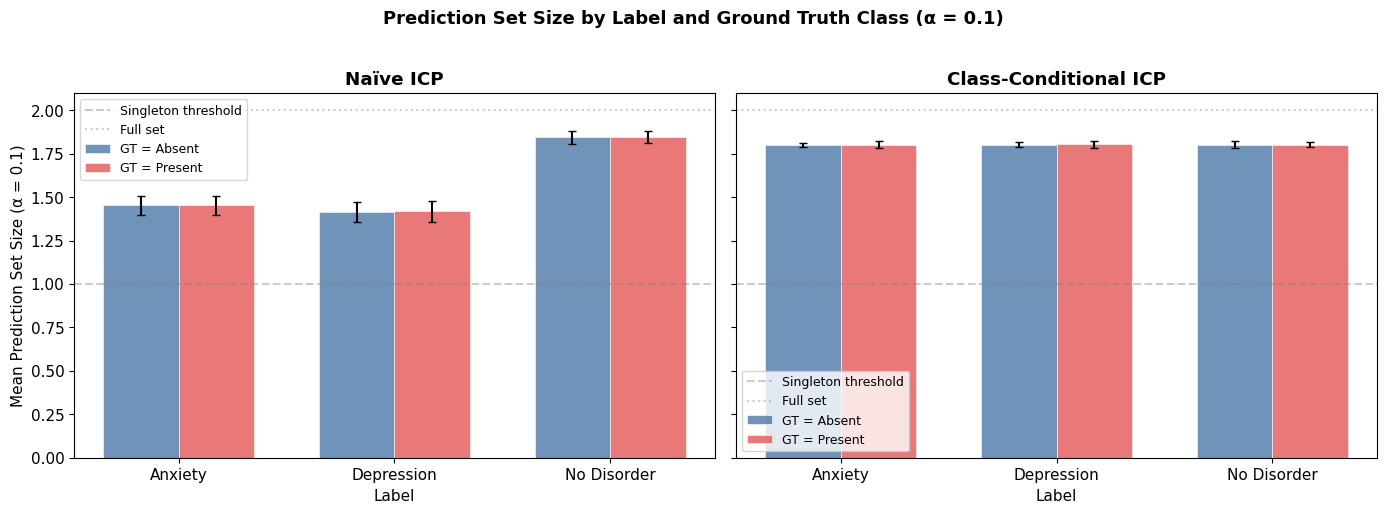

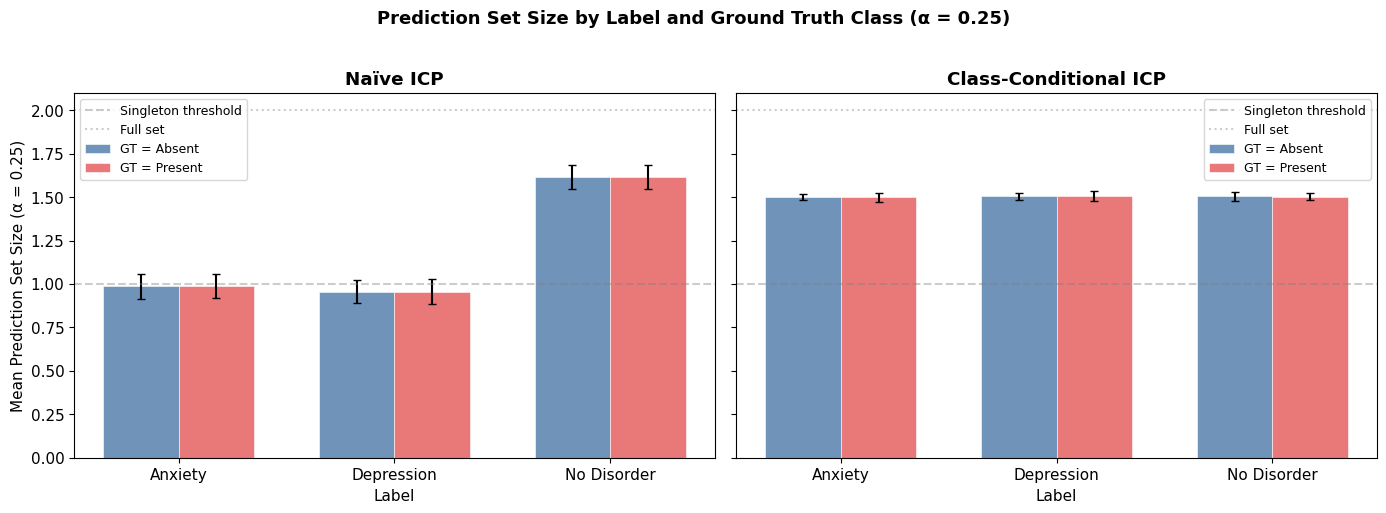

In [16]:
methods = [('Naïve ICP', df_naive), ('Class-Conditional ICP', df_cc)]

for alpha in ALPHAS:
    plot_efficiency_by_ground_truth(
        alpha, methods, LABEL_NAMES, CLASS_NAMES,
    )

## Summary of Findings

**Key observations from the stratified efficiency analysis:**

**1. Within-label set sizes are symmetric across ground truth classes.**  
For both Naïve and Class-Conditional ICP, the mean prediction set sizes for truly-absent vs. truly-present examples are nearly identical within each label. The CP methods do not produce notably different set sizes depending on whether the condition is actually present or absent.

**2. The primary efficiency variation is across labels, not within them.**  
For Naïve ICP at α=0.1, Anxiety (~1.45, ~55% singleton) and Depression (~1.42, ~58% singleton) show substantially smaller set sizes than No Disorder (~1.85, ~15% singleton). This reflects the base classifier's probability distributions: because Anxiety and Depression are rare, predicted probabilities cluster near zero, producing sharper nonconformity score distributions.

**3. Class-Conditional ICP produces uniform set sizes by design.**  
By calibrating separately within each class value, CC-ICP yields near-identical set size distributions (~1.80, ~20% singleton) across all labels and ground truth classes. This equalization of coverage (reported in Table 4 and Fig. 5 of the manuscript) comes at the cost of larger, less efficient prediction sets.

**4. The asymmetry between methods lies in singleton *correctness*, not set *size*.**  
While set sizes are symmetric within each label, the singleton correctness analysis (Section 4) reveals the underlying discrimination: Naïve ICP singletons for the majority class are more often correct than for the minority class, reflecting the coverage imbalance documented in Table 4.

**Interpretation:** Prediction set efficiency is driven primarily by label-level prevalence characteristics rather than individual-level ground truth status. This reinforces the complementary roles of the two ICP approaches: Naïve ICP achieves greater efficiency (smaller sets) but with unbalanced coverage, while Class-Conditional ICP ensures equitable per-class coverage at the expense of larger prediction sets.